In [1]:
pip install yfinance

Note: you may need to restart the kernel to use updated packages.


Failed to get ticker 'AAPL' reason: Failed to perform, curl: (28) Operation timed out after 10002 milliseconds with 0 bytes received. See https://curl.se/libcurl/c/libcurl-errors.html first for more details.
[*********************100%***********************]  1 of 1 completed


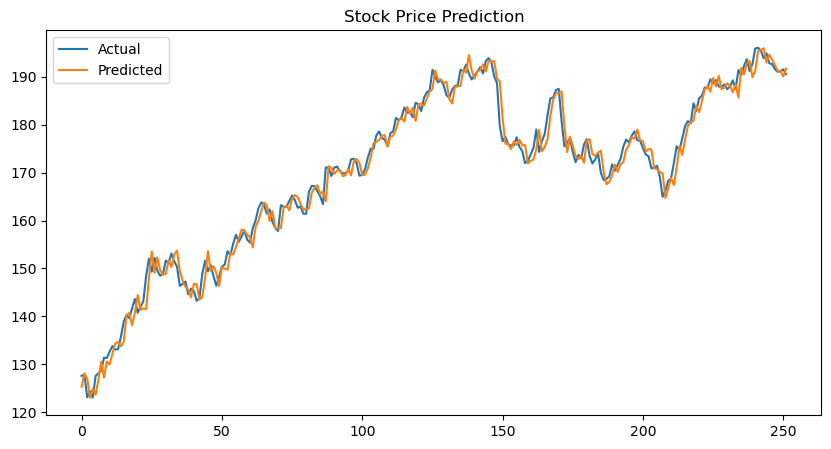

In [1]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

# Load stock data
data = yf.download('AAPL', start='2020-01-01', end='2024-01-01')

# Features & target
data['Next_Close'] = data['Close'].shift(-1)
data = data.dropna()

X = data[['Open', 'High', 'Low', 'Volume']]
y = data['Next_Close']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, shuffle=False)

# Model
model = LinearRegression()
model.fit(X_train, y_train)

# Predictions
predictions = model.predict(X_test)

# Plot
plt.figure(figsize=(10,5))
plt.plot(y_test.values, label='Actual')
plt.plot(predictions, label='Predicted')
plt.legend()
plt.title("Stock Price Prediction")
plt.show()